# Skimming

The ntuples are very large, especially for data, and most of their content is background.
For reducing their size, it is advisable to perform an initial selection based on trigger and kinematic variables.
We will start with the trigger selection and search for useful kinematic variables later.

To guide us in the selection we will use the signal Monte Carlo sample, which has been selected as the same as the data.
Data sidebands will be used to represent the background that we want to suppress.

## Online Selection

In the online selection of the events, at HLT2 level, it is required that our signal candidates (`Hlt2RD_TauToMuMuMu`) satisfy the following conditions

- $\tau\to µµµ$
    - track candidates: PIDµ > 0, GhostProbability < 0.5, $\chi^2_{\text{trk}}$<4
    - at least 2 muons satisfying IS_MUON
    - 0 < $m_{µ_1µ_2}$ < 1800 MeV/$c^2$
    - $\chi^2_{\text{IP}}$ < 3000

The control channel (`Hlt2RD_DsToPhiPi_PhiToMuMu`) is instead selected by 

- $D_s\to\phi(1020)(\to µµ)\pi$:
    - µ: IS_MUON, PIDµ > 0, GhostProbability < 0.5, $\chi^2_{\text{trk}}$<4
    - π: GhostProbability < 0.5, $\chi^2_{\text{trk}}$<4
    - 1718 MeV/$c^2$ < $m_{µµπ}$ < 2218 MeV/$c^2$
    - 950 MeV/$c^2$ < $m_{µ_1µ_2}$ < 1090 MeV/$c^2$
    - $\chi^2_{\text{IP}}$ < 3000

### 2-µ vs. 3-µ Sample

As can be seen from the $\tau\to µµµ$ selection, `IS_MUON`, i.e. specific binary selection based on information from the muon stations

- IS_MUON
    - p < 3 GeV/c: Never classified as a muon.
    - 3 < p < 6 GeV/c: Requires hits in M2 & M3.
    - 6 < p < 10 GeV/c: Requires hits in M2 & M3 & (M4 || M5).
    - p > 10 GeV/c: Requires hits in M2 & M3 & M4 & M5

is required for at least two of the three muons. This allow us to identify two categories of selected events: those for which all 3 muons are identified as `IS_MUON`, and those with only 2 out of 3 muons identified.


In [220]:
import os
import uproot
import yaml
from importlib.resources import files

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [221]:
data_samples = yaml.safe_load(open('../data/testing_ap.yaml', 'r'))
event_id = [21513012, 21513013, 23513015, 23513016, 31113003] # only tau events

sample_MC = uproot.open(data_samples[f'mc-{event_id[0]}'][0])
keys = sample_MC['Tau2MuMuMu/DecayTree'].keys()

Variables considered

In [222]:
muon_var = [k for k in keys if 'ISMUON' in k]
hlt1_tos_var = [k for k in keys if 'Hlt1' in k and 'TOS' in k]
hlt1_tis_var = [k for k in keys if 'Hlt1' in k and 'TIS' in k]

#kinematic variables
kin_var = ['Tau_M', 'Tau_PT']            
muon_p_var = ['mu2_PX', 'mu2_PY', 'mu2_PZ']

variables = muon_var + hlt1_tos_var + hlt1_tis_var + kin_var + muon_p_var 

MC dataset

In [223]:
df_mc = []

for event in event_id:
    MC_np = uproot.open(data_samples[f'mc-{event}'][0])['Tau2MuMuMu/DecayTree'].arrays(variables, library="np") # faster via np
    MC_df = pd.DataFrame(MC_np) 
    df_mc.append(MC_df)
    
df_MC = pd.concat(df_mc, ignore_index=True)
print(len(df_MC))

878758


MC dataset divided in 2 $\mu$ and 3 $\mu$

In [224]:
separator = df_MC[muon_var].astype(int).sum(axis=1)

df_3mu_MC = df_MC[separator == 3].copy()
df_2mu_MC = df_MC[separator == 2].copy()

print(len(df_2mu_MC))
print(len(df_3mu_MC))

223473
655285


* The global MC sample consists of df_3mu_MC ~75% and df_2mu_MC ~25% .

## Trigger Selection

LHC collides protons at 13.6TeV center-of-mass energy with a rate of 40 MHz.
LHCb selects events online through a 2-step approach:

1. Hlt1: a GPU farm performs initial reconstruction of the data and reduces the data rate from 40MHz to up to 1.5 MHz
2. Hlt2: a CPU farm performs the full reconstruction of the data, runs most of the selections of particle candidates and reduces the data rate to about 30KHz, corresponding to 10Gb/s stored to disk.

![RTA dataflow](https://lhcb-glance.cern.ch/alcm/public/figure/details/32#:~:text=RTA_dataflow_widescreen.pdf)

Since our candidates selected at HLT2 may have passed various selections at HLT1, we want to identify those that are most efficient to reduce background levels and define a specific trigger sequence to simplify the efficiency determination.

To determine whether the candidate has been selected by a specific Hlt1 line or not, the following variables are stored in the tuples:

- `Hlt1_<name>Decision_TOS`: Trigger On Signal, the tracks used to build our particle candidate fired the trigger line
- `Hlt1_<name>Decision_TIS`: Trigger Independently of Signal, the tracks used to build our particle candidate were not involved in the firing of the trigger line

In [225]:
# Since the dataframe can contain arrays (where there are _SUBCOMB) but single boolean values are required,
# this function take them into a single True/False per event
def bool_value(x):
    if isinstance(x, np.ndarray):
        return np.any(x)
    return x

In [226]:
# arrays in df are only in _SUBCOMB lines:

#def search_array_in_df(df):
#    array_columns = {}
    
#    for col in df.columns:
#        col_values = df[col]
#        values = col_values.iloc[0]

#        if isinstance(values, (np.ndarray, list)):
#            array_columns[col] = values

#    for col, find_array in array_columns.items():
#        print(f"'{col}': {find_array}")

#search_array_in_df(df_MC)

Function to determine the trigger efficiency

In [227]:
def trigger_efficiency (ds_name, df):  

    tot_events = len(df)  

    # TOS efficiencies 
    tos_eff = {}
    tos_col = {}
    for col in hlt1_tos_var:
        name = col.replace('TOS', '').replace('Hlt1', '').replace('Decision', '').strip('_')
        tos_col[name] = col
        count = df[col].apply(bool_value).sum()
        tos_eff[name] = count / tot_events

    # TIS efficiencies 
    tis_eff = {}
    tis_col = {}
    for col in hlt1_tis_var:
        name = col.replace('TIS', '').replace('Hlt1', '').replace('Decision', '').strip('_')
        tis_col[name] = col
        count = df[col].apply(bool_value).sum()
        tis_eff[name] = count / tot_events

    # Filters: remove SUBCOMB and require at least one efficiency > 10%
    labels = []
    tos_efficiencies = []
    tis_efficiencies = []

    trigger_lines = tos_eff.keys() | tis_eff.keys()
    
    for line in trigger_lines:
        if 'SUBCOMB' in line: # exclude subcombination (give same TOS results)
            continue
            
        eff_tos = tos_eff.get(line, 0.0)  # handle missing lines in TIS or TOS
        eff_tis = tis_eff.get(line, 0.0)

        if eff_tos > 0.10 or eff_tis > 0.10:
            labels.append(line)
            tos_efficiencies.append(eff_tos)
            tis_efficiencies.append(eff_tis)

    # Sort by descending TOS efficiency
    sort = np.argsort(tos_efficiencies)[::-1]
    labels = [labels[i] for i in sort]
    tos_efficiencies = [tos_efficiencies[i] for i in sort]
    tis_efficiencies = [tis_efficiencies[i] for i in sort]

    # Combined efficiency of the two most efficient lines
    top_two = labels[:2]
    top_tos_cols = [tos_col[name] for name in top_two]
    top_tis_cols = [tis_col[name] for name in top_two]

    combined_tos = df[top_tos_cols].any(axis=1).sum() / tot_events
    combined_tis = df[top_tis_cols].any(axis=1).sum() / tot_events

    labels.append(f"{top_two[0]} OR {top_two[1]}")
    tos_efficiencies.append(combined_tos)
    tis_efficiencies.append(combined_tis)

    

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(11, 6))

    ax.bar(x - width/2, tos_efficiencies, width, label='TOS')
    ax.bar(x + width/2, tis_efficiencies, width, label='TIS')
    ax.axvline(x=len(labels) - 1.5, color='gray', linestyle='--')

    ax.set_ylabel('Efficiency')
    ax.set_title(f'Sample {ds_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 2 $\mu$ sample

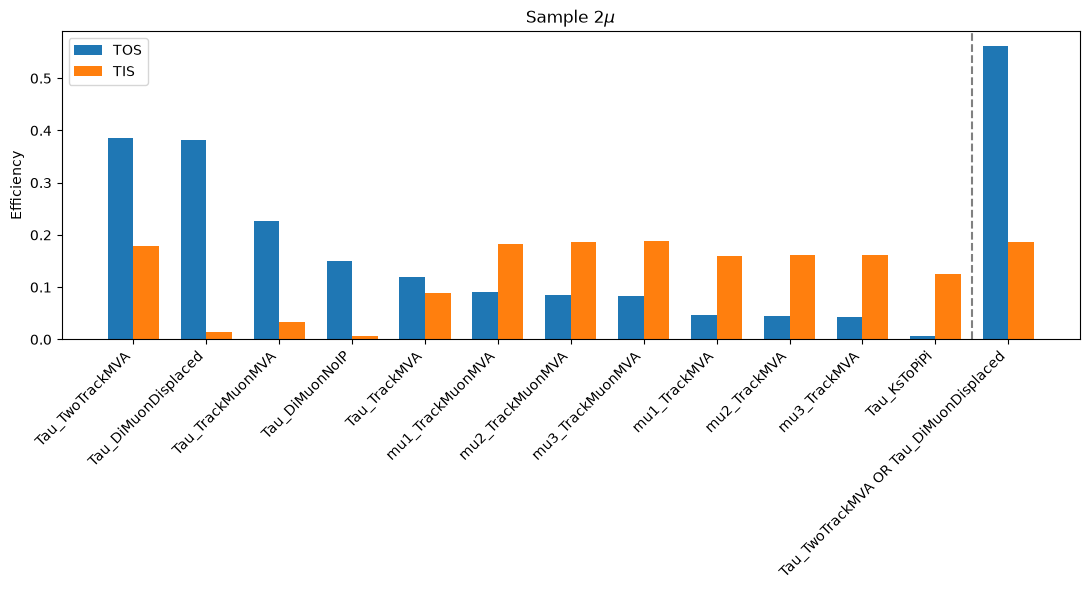

In [228]:
trigger_efficiency('2$\\mu$', df_2mu_MC)

### 3 $\mu$ sample

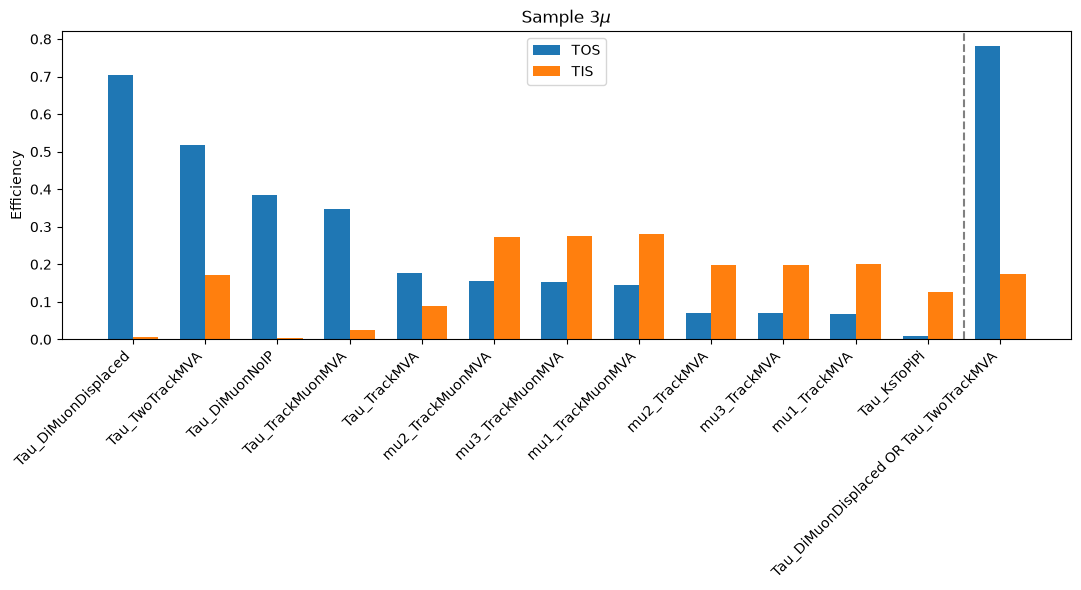

In [229]:
trigger_efficiency('3$\\mu$', df_3mu_MC)

##### OBSERVATIONS

* The highest performances are achieved by calculating the combined efficiency of DiMuonDisplaced and TwoTrackMVA in df_3mu_MC

* The df_2mu_MC sample shows an efficiency drop on the DiMuonDisplaced line, probably because of the missing fully reconstructed muon


## Selection cuts

variables to test for the cuts

In [230]:
vars_test = ['Tau_PT'] +  muon_p_var 

Real-data dataset divided in 2 $\mu$ and 3 $\mu$ samples

In [231]:
data = uproot.open(data_samples['data'][0])
df_data_np = data['Tau2MuMuMu/DecayTree'].arrays(variables, library="np")
df_data = pd.DataFrame(df_data_np)

separator = df_data[muon_var].astype(int).sum(axis=1)
df_3mu_data = df_data[separator == 3].copy()
df_2mu_data = df_data[separator == 2].copy()


print(len(df_data))
print(len(df_2mu_data))
print(len(df_3mu_data))

992670
926285
66385


Function to select only the events passing the two most efficient trigger lines. It is applied prior to optimizing the cuts

In [232]:
def trigger_filter(df): 
    col_1 = 'Tau_Hlt1DiMuonDisplacedDecision_TOS'
    col_2 = 'Tau_Hlt1TwoTrackMVADecision_TOS'

    mask1 = df[col_1]                                                                                                           
    mask2 = df[col_2]
    return df[mask1 | mask2].copy()

Function to compare the normalized distributions of a given variable for signal (MC) and background (data sidebands)

In [233]:
def plot_variable_sign_bkg(df_data, df_mc, variable):

    lower_sb = (df_data['Tau_M'] > 1600) & (df_data['Tau_M'] < 1757) #from LHCb Run2 Analysis
    upper_sb = (df_data['Tau_M'] > 1797) & (df_data['Tau_M'] < 1950)

    bkg_df = df_data[lower_sb | upper_sb].copy()
    sig_df = df_mc.copy()

    bkg_vals = bkg_df[variable]
    sig_vals = sig_df[variable]
     
    plt.hist(bkg_vals, bins=50, density=True, alpha=0.7, label='Background')
    plt.hist(sig_vals, bins=50, density=True, alpha=0.7, label='Signal')
        
    plt.xlabel(variable)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

### 2 $\mu$ sample

In [234]:
df_2mu_mc_trig = trigger_filter(df_2mu_MC) 
df_2mu_data_trig = trigger_filter(df_2mu_data) 

print(len(df_2mu_mc_trig))
print(len(df_2mu_data_trig))

125539
362315


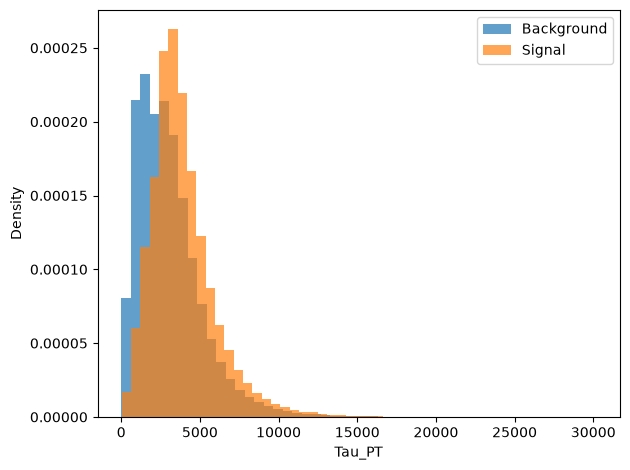

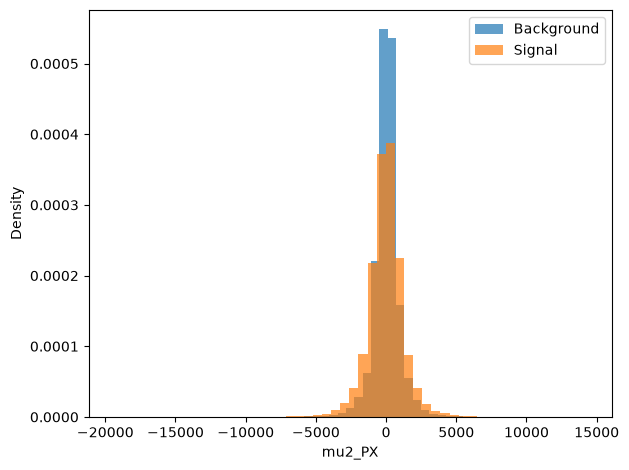

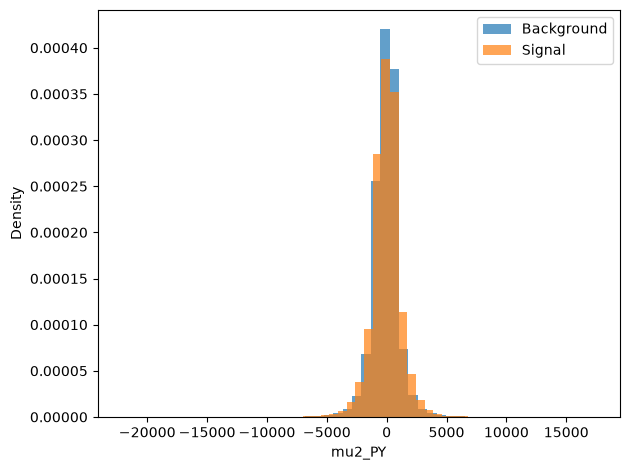

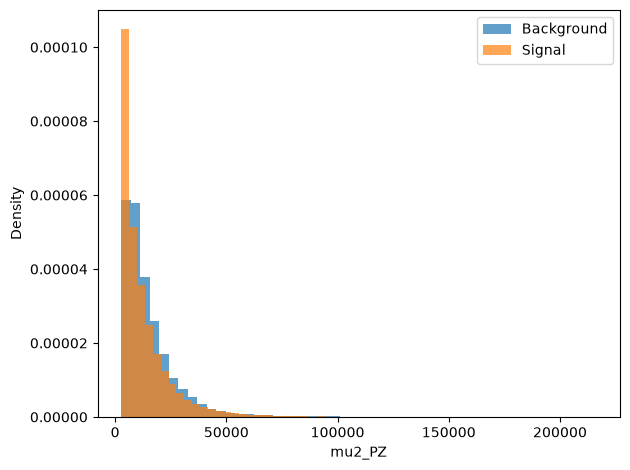

In [235]:
for var in vars_test:
        plot_variable_sign_bkg(df_2mu_data_trig, df_2mu_mc_trig , var)

### 3 $\mu$ sample

In [236]:
df_3mu_mc_trig = trigger_filter(df_3mu_MC)
df_3mu_data_trig = trigger_filter(df_3mu_data)

print(len(df_3mu_mc_trig))
print(len(df_3mu_data_trig))

512014
40599


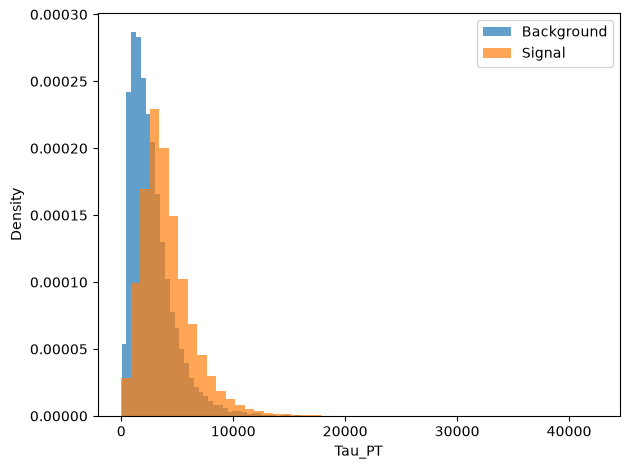

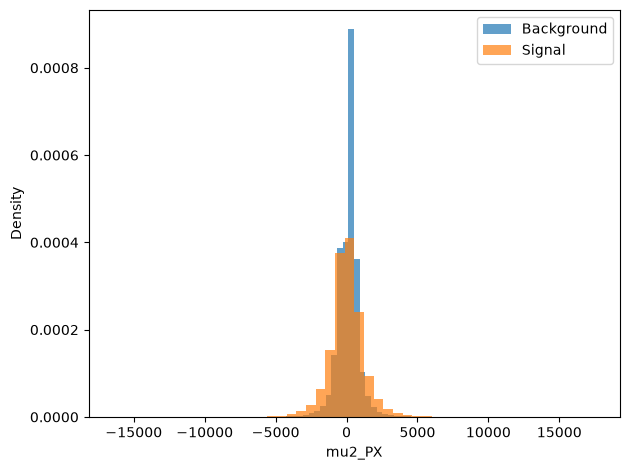

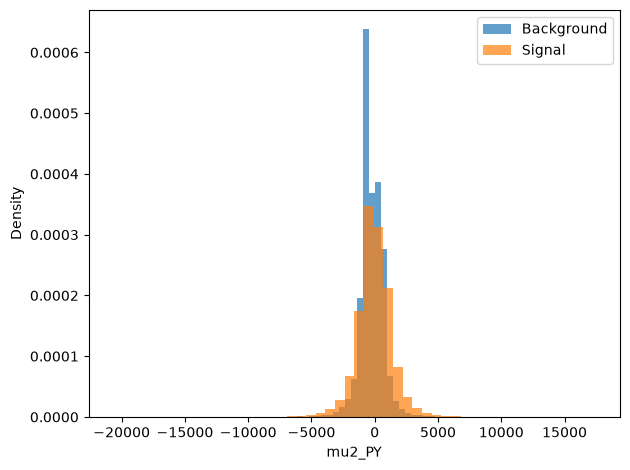

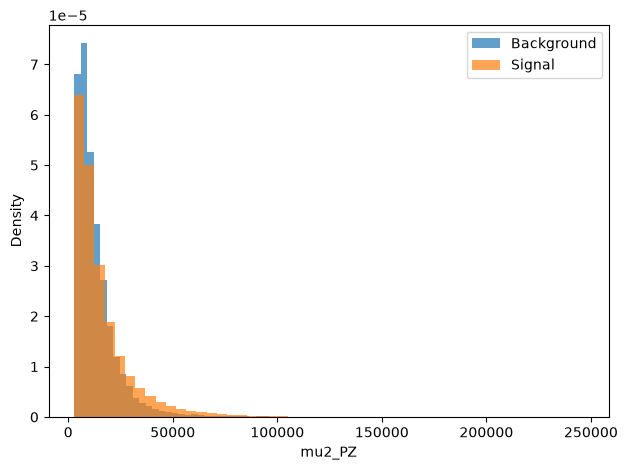

In [237]:
for var in vars_test:
        plot_variable_sign_bkg(df_3mu_data_trig, df_3mu_mc_trig , var)

##### OBSERVATIONS

* It seems that cuts would be ineffective in both cases. The most significant separation between background and signal is observed primarily in the $p_T$ distribution.

---
The [LHCb Run 2 analysis](https://arxiv.org/pdf/2601.20785)  excludes the 2mu category because the larger background contamination and hardware trigger limitations make its statistical contribution to the upper limit negligible (pag. 4):

" It is also possible to reconstruct decays in which one of the muons falls outside the acceptance of the muon system or has insufficient momentum to penetrate it, by considering candidates for which only two tracks satisfy the muon-identification requirements of the analysis. However, the larger background contamination, together with the limitations of the hardware trigger, which primarily selects tracks with high $p_{T}$, make the sensitivity to the $\tau^{-}\rightarrow\mu^{-}\mu^{+}\mu^{-}$ channel significantly worse than in the case where all tracks are identified as muons. The contribution of this category to the upper limit is found to be negligible and is therefore excluded from the final result presented in this paper."

